In [3]:
import numpy as np

import os 
import sys
sys.path.append("..//utils/")
import color_utils, make_data_dict
import format_waveform_data, waveform_analysis, waveform_plots
import matplotlib.pyplot as plt

root_dir = "Z:/Isabel/data/hpc_implants/"
save_figs = f"../figures/basic_neural_analysis/"
save_data = f'{root_dir}stim_session_data.npy'

In [4]:
data_dict = np.load(save_data, allow_pickle=True).item()

In [7]:
bird_ids = []
for bird in data_dict.keys():
    bird_ids.append(bird)

In [11]:
for bird in bird_ids:
    print(f'\ncollecting session info for {bird}')
    bird_dir = f"{root_dir}{bird}/"
    session_list = data_dict[bird]['all_sessions']
    
    behavior_sessions = []
    waveform_sessions = []
    stim_sessions = []
    for session_id in session_list:
        if 'behavior' in data_dict[bird][session_id]['preprocessed_data']:
            behavior_sessions.append(session_id)
        if 'ephys' in data_dict[bird][session_id]['preprocessed_data']:
            waveform_sessions.append(session_id)
        if 'stim' in data_dict[bird][session_id]['preprocessed_data']:
            stim_sessions.append(session_id)
            
    # check for fully preprocessed sessions
    complete_sessions = list(set(behavior_sessions) & set(waveform_sessions) & set(stim_sessions))
    print(f"{len(waveform_sessions)} have sorted and curated ephys: \n{waveform_sessions}")
    print(f"{len(stim_sessions)} have stim: \n{stim_sessions}")
    print(f"{len(behavior_sessions)} have annotated behavior: \n{behavior_sessions}")
    print(f"{len(complete_sessions)} total sessions have complete data (ephys, stim, and behavior)")
    print(f"complete session IDs: {complete_sessions}")


collecting session info for LIM63
1 have sorted and curated ephys: 
['240610']
2 have stim: 
['240607', '240610']
0 have annotated behavior: 
[]
0 total sessions have complete data (ephys, stim, and behavior)
complete session IDs: []

collecting session info for RBY94
1 have sorted and curated ephys: 
['241129']
3 have stim: 
['241121', '241125', '241129']
1 have annotated behavior: 
['241129']
1 total sessions have complete data (ephys, stim, and behavior)
complete session IDs: ['241129']

collecting session info for AMB154
6 have sorted and curated ephys: 
['241112', '241114', '241119', '241122', '241127', '241202']
6 have stim: 
['241112', '241114', '241119', '241122', '241127', '241202']
4 have annotated behavior: 
['241119', '241122', '241127', '241202']
4 total sessions have complete data (ephys, stim, and behavior)
complete session IDs: ['241119', '241127', '241122', '241202']

collecting session info for SLV132
8 have sorted and curated ephys: 
['250303', '250310', '250318', '

In [ ]:
# check for fully preprocessed sessions
complete_sessions = list(set(behavior_sessions) & set(waveform_sessions) & set(stim_sessions))
print(f"{len(waveform_sessions)} have sorted and curated ephys")
print(f"{len(stim_sessions)} have stim")
print(f"{len(behavior_sessions)} have annotated behavior")
print(f"{len(complete_sessions)} total sessions have complete data (ephys, stim, and behavior)")
print(f"complete session IDs: {complete_sessions}")

In [2]:
''' Load/create the dictionary of waveform data for all good stim sessions '''
# load or create data dictionary and get bird list
bird_ids = []
if os.path.isfile(save_data):
    data_dict = np.load(save_data, allow_pickle=True).item()
    for bird in data_dict.keys():
        bird_ids.append(bird)
    print(f'current birds with saved data: {bird_ids}')
    modify_dict = input("modify data dictionary? (y/n)")
    if modify_dict == 'y':
        data_dict = make_data_dict.modify_data_dict(root_dir, save_data)
else:
    data_dict = make_data_dict.modify_data_dict(root_dir, save_data)

# update bird list
for bird in data_dict.keys():
    if bird in bird_ids:
        continue
    else:
        bird_ids.append(bird)

input number of birds: 6
input bird 1 ID: LIM63
input bird 2 ID: RBY94
input bird 3 ID: AMB154
input bird 4 ID: SLV132
input bird 5 ID: IND67
input bird 6 ID: LMN146

LIM63 has 8 total sessions
3 have ephys (1 sorted and curated)
2 have stim
0 have annotated behavior
0 total sessions have complete data (ephys, stim, and behavior)
complete session IDs: []

RBY94 has 6 total sessions
5 have ephys (1 sorted and curated)
3 have stim
1 have annotated behavior
1 total sessions have complete data (ephys, stim, and behavior)
complete session IDs: ['241129']

AMB154 has 8 total sessions
11 have ephys (3 sorted and curated)
6 have stim
1 have annotated behavior
1 total sessions have complete data (ephys, stim, and behavior)
complete session IDs: ['241119']

SLV132 has 15 total sessions
13 have ephys (8 sorted and curated)
9 have stim
5 have annotated behavior
4 total sessions have complete data (ephys, stim, and behavior)
complete session IDs: ['250303', '250326', '250310', '250328']

IND67 has 

In [8]:
''' Load and organize the waveform properties '''
for bird in bird_ids:
    print(f'\ncollecting waveform data for {bird}')
    bird_dir = f"{root_dir}{bird}/"
    session_list = data_dict[bird]['all_sessions']
    for session_id in session_list:
        # only calculate for new data
        if 'waveform_props' in data_dict[bird][session_id].keys():
                continue

        # specify the file paths
        if 'ephys' in data_dict[bird][session_id]['preprocessed_data']:
            session_dir = f'{bird_dir}/{bird}_{session_id}/'
            for folder in os.listdir(session_dir):
                if f'{bird}_{session_id}' in folder:
                    ephys_id = folder[-13:]
            
            for file in os.listdir(f"{session_dir}{bird}_{ephys_id}"):
                if 'kilosort4' in file:
                    ks_dir = f"{bird}_{ephys_id}/{file}/"
                    ephys_dir = f"{session_dir}{bird}_{ephys_id}/raw_ephys_output/"

                    # load and format the waveform struct
                    waveform_struct = format_waveform_data.load_wf_data(session_dir, ks_dir=ks_dir)
                    wf_ids = waveform_struct['goodIDs']
                    mean_waveforms, wf_channels, _, ch_names = format_waveform_data.sort_wf_by_channel('', waveform_struct,
                                                                                                       data_dir=ephys_dir,
                                                                                                       return_ch_names=True)       
                    n_cells = mean_waveforms.shape[0]
                    wf_ch_idx = np.asarray([ch_names.index(ch) for ch in wf_channels])

                    # calculate the waveform properties
                    fr = waveform_struct['meanRate']
                    log_fr = np.log10(fr)
                    width = np.zeros(n_cells)
                    asymm = np.zeros(n_cells)
                    for wf_idx in range(n_cells):
                        best_ch = wf_ch_idx[wf_idx]
                        width[wf_idx] = waveform_analysis.calc_spike_width(mean_waveforms[wf_idx, best_ch])
                        asymm[wf_idx] = waveform_analysis.calc_amp_assym(mean_waveforms[wf_idx, best_ch])  

                    # save by session and overall
                    waveform_props = np.row_stack([asymm, width, log_fr])
                    data_dict[bird][session_id]['waveform_props'] = waveform_props
                    if 'all_waveform_props' in data_dict[bird].keys():
                        all_props = data_dict[bird]['all_waveform_props']
                        data_dict[bird]['all_waveform_props'] = np.column_stack([all_props, waveform_props])
                    else:
                        data_dict[bird]['all_waveform_props'] = waveform_props


collecting waveform data for LIM63
Z:/Isabel/data/hpc_implants/LIM63//LIM63_240610/LIM63_240610_131820/kilosort4_hash_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spkDur', 'spkOffset', 'goodIDs', 'goodLabels', 'medISI', 'contam', 'nSpikes'])
Z:/Isabel/data/hpc_implants/LIM63//LIM63_240610/LIM63_240610_131820/raw_ephys_output/intan_info.mat

collecting waveform data for RBY94
Z:/Isabel/data/hpc_implants/RBY94//RBY94_241129/RBY94_241129_112536/kilosort4_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spkDur', 'spkOffset', 'goodIDs', 'goodLabels', 'medISI', 'contam', 'nSpikes'])
Z:/Isabel/data/hpc_implants/RBY94//RBY94_241129/RBY94_241129_112536/raw_ephys_output/intan_info.mat

collecting waveform data for AMB154
Z:/Isabel/data/hpc_implants/AMB154//AMB154_241112/AMB154_241112_114129/kilosort4_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spk

KeyboardInterrupt: 

In [6]:
for i, bird in enumerate(bird_ids):
    if i == 0:
        all_waveform_props = data_dict[bird]['all_waveform_props']
    else:
        waveform_props = data_dict[bird]['all_waveform_props']
        all_waveform_props = np.column_stack([all_waveform_props, waveform_props])

In [13]:
# save the dict for future use
np.save(f'{save_data}stim_session_data.npy', data_dict)

In [7]:
# get the cluster indices - swap as needed so interneurons are clu2
asymm = all_waveform_props[0]
width = all_waveform_props[1]
log_fr = all_waveform_props[2]
clu1_idx, clu2_idx = waveform_analysis.clu_waveforms_kmeans(width, asymm, log_fr)
if np.sum(clu1_idx) < np.sum(clu2_idx):
    clu1_idx_temp = clu2_idx.copy()
    clu2_idx = clu1_idx
    clu1_idx = clu1_idx_temp
n_excite = np.sum(clu1_idx)
n_cells = all_waveform_props.shape[1]
print(f'\n{n_excite}/{n_cells} cells are putative excitatory neurons ({np.round((n_excite/n_cells)*100, 1)}%)')

C:\Users\ilow1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(



1966/2144 cells are putative excitatory neurons (91.7%)


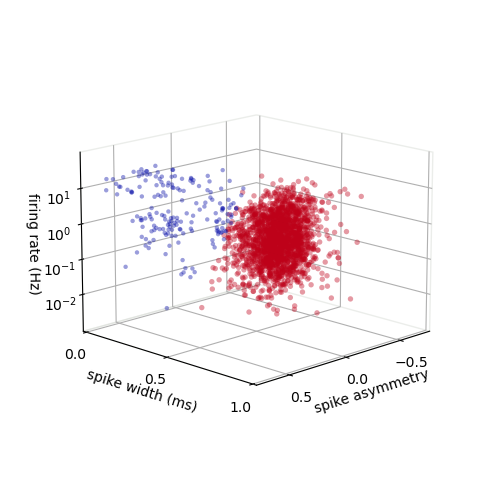

In [8]:
# plot the waveform property clusters
fig, ax = waveform_plots.plot_wf_clusters(asymm, width, log_fr, clu1_idx, clu2_idx)
fig.savefig(f'{save_figs}waveform_props.png', 
                      dpi=600, bbox_inches='tight')

In [124]:
''' cluster with a gmm '''
from sklearn.mixture import GaussianMixture

for i, bird in enumerate(bird_ids):
    if i == 0:
        all_waveform_props = data_dict[bird]['all_waveform_props']
    else:
        waveform_props = data_dict[bird]['all_waveform_props']
        all_waveform_props = np.column_stack([all_waveform_props, waveform_props])

asymm = all_waveform_props[0]
width = all_waveform_props[1]
log_fr = all_waveform_props[2]

# consolidate the params for clustering
wf_params = np.column_stack([asymm, width])
wf_params = np.column_stack([wf_params, log_fr])

# fit a Gaussian mixture model
wf_model = GaussianMixture(n_components=2)
wf_model.fit(wf_params)

C:\Users\ilow1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


GaussianMixture(n_components=2)

In [133]:
# get the probability that each cell belongs to each cluster
probs = wf_model.predict_proba(wf_params)

# label each cell by its best cluster (excitatory is clu1)
labels = probs > 0.8
n_cells_clu = np.sum(labels, axis=0)
clu_idx = np.argsort(n_cells_clu)
sorted_labels = labels[:, clu_idx]

clu1_idx = sorted_labels[:, -1]
clu2_idx = sorted_labels[:, -2]
# clu3_idx = sorted_labels[:, 0]
clu_none_idx = np.abs((clu1_idx + clu2_idx) - 1).astype(bool)

In [134]:
import matplotlib.ticker as mticker

def log_tick_formatter(val, pos=None):
    return f"$10^{{{val:g}}}$"

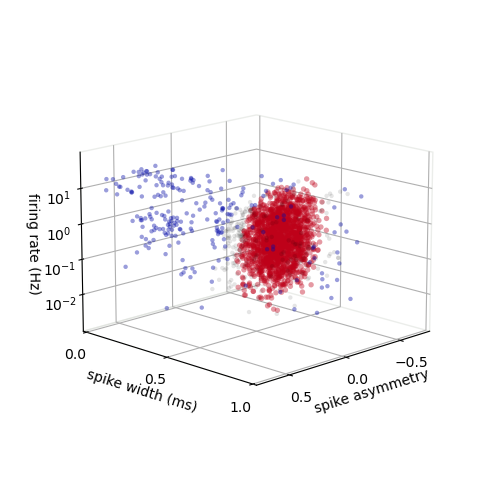

In [136]:
fig = plt.figure(figsize=(8, 4))
ax = plt.axes([0, 0, .6, 1.2], projection='3d')

# # all excitatory cells
ax.scatter(asymm[clu1_idx],
           width[clu1_idx],
           log_fr[clu1_idx],
           c='xkcd:scarlet',
           alpha=0.4, lw=0, s=15, zorder=0)

# all inhibitory cells
ax.scatter(asymm[clu2_idx],
           width[clu2_idx],
           log_fr[clu2_idx],
           c='xkcd:cobalt blue', 
           alpha=0.4, lw=0, s=10, zorder=0)

# other...
ax.scatter(asymm[clu_none_idx],
           width[clu_none_idx],
           log_fr[clu_none_idx],
           c='k', 
           alpha=0.1, lw=0, s=10, zorder=0)

# labels
ax.set_xlabel('spike asymmetry')
ax.set_ylabel('spike width (ms)')
ax.set_zlabel('firing rate (Hz)')

# log scale the z-axis
ax.zaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.zaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# limits
ax.set_xlim([-0.75, 0.75])
ax.set_xticks([-0.5, 0, 0.5])
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])

# background color
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('xkcd:grey')
ax.yaxis.pane.set_edgecolor('xkcd:grey')
ax.zaxis.pane.set_edgecolor('xkcd:grey')
ax.xaxis.pane.set_color('xkcd:light grey')
ax.yaxis.pane.set_color('xkcd:light grey')
ax.zaxis.pane.set_color('xkcd:light grey')

ax.view_init(azim=45, elev=15)
ax.set_box_aspect(aspect=None, zoom=0.8)
plt.show()

fig.savefig(f'{save_figs}waveform_props_gmm.png', 
                      dpi=600, bbox_inches='tight')

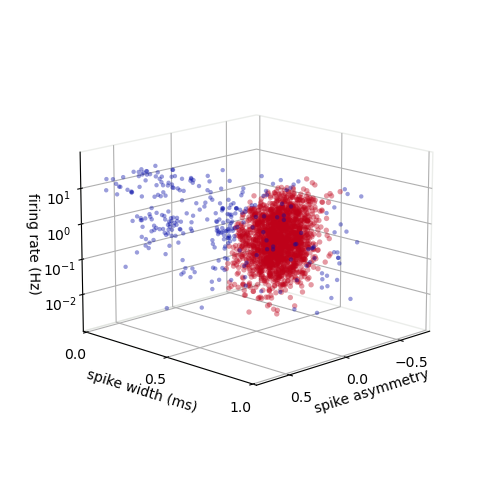

In [83]:
# plot the waveform property clusters
fig, ax = waveform_plots.plot_wf_clusters(asymm, width, log_fr, clu1_idx, clu2_idx)
# fig.savefig(f'{save_figs}waveform_props_gmm.png', 
#                       dpi=600, bbox_inches='tight')

In [ ]:
f1_slow = stats.norm(model_slow.means_[0], np.sqrt(model_slow.covariances_[0]))
f2_slow = stats.norm(model_slow.means_[1], np.sqrt(model_slow.covariances_[1]))

In [28]:
# plot the cumulative firing rates by session and by bird
session_rates = []
session_bins = []
bird_rates = []
bird_bins = []
session_idx_s = 0
bird_idx_s = 0
for bird in bird_ids:
    for session_id in data_dict[bird]['complete_sessions']:
        waveform_props = data_dict[bird][session_id]['waveform_props']
        log_fr = waveform_props[2]
        
        # filter out interneurons
        n_cells = log_fr.shape[0]
        session_idx_e = session_idx_s + n_cells
        session_clu1_idx = clu1_idx[session_idx_s:session_idx_e]
        session_idx_s = session_idx_e
        print(f'{bird}_{session_id}: {np.sum(session_clu1_idx)}/{n_cells} cells are excitatory')
        
        # collect the normalized rates by session
        norm_rates, bin_vals = waveform_analysis.calc_cum_rates(log_fr[session_clu1_idx])
        session_rates.append(norm_rates)
        session_bins.append(bin_vals)
    
    
    # collect the normalized rates by bird
    waveform_props = data_dict[bird]['all_waveform_props']
    log_fr = waveform_props[2]
    
    # filter out interneurons
    n_cells = log_fr.shape[0]
    bird_idx_e = bird_idx_s + n_cells
    bird_clu1_idx = clu1_idx[bird_idx_s:bird_idx_e]
    bird_idx_s = bird_idx_e
    print(f'{bird}: {np.sum(bird_clu1_idx)}/{n_cells} cells are excitatory\n')
        
    norm_rates, bin_vals = waveform_analysis.calc_cum_rates(log_fr[bird_clu1_idx])
    bird_rates.append(norm_rates)
    bird_bins.append(bin_vals)

RBY94_241129: 82/101 cells are excitatory
*RBY94: 82/101 cells are excitatory*

AMB154_241119: 94/115 cells are excitatory
*AMB154: 94/115 cells are excitatory*

SLV132_250328: 118/128 cells are excitatory
SLV132_250303: 104/110 cells are excitatory
SLV132_250326: 60/64 cells are excitatory
SLV132_250310: 89/96 cells are excitatory
*SLV132: 371/398 cells are excitatory*

IND67_251014: 80/82 cells are excitatory
IND67_251021: 94/102 cells are excitatory
IND67_251016: 105/109 cells are excitatory
IND67_250918: 24/24 cells are excitatory
IND67_250925: 107/117 cells are excitatory
IND67_250929: 99/105 cells are excitatory
IND67_251001: 151/159 cells are excitatory
IND67_251010: 72/74 cells are excitatory
IND67_251006: 82/84 cells are excitatory
IND67_251008: 125/134 cells are excitatory
IND67_251003: 129/137 cells are excitatory
*IND67: 1068/1127 cells are excitatory*

LMN146_251121: 59/78 cells are excitatory
LMN146_251107: 61/62 cells are excitatory
LMN146_251112: 47/50 cells are excitat

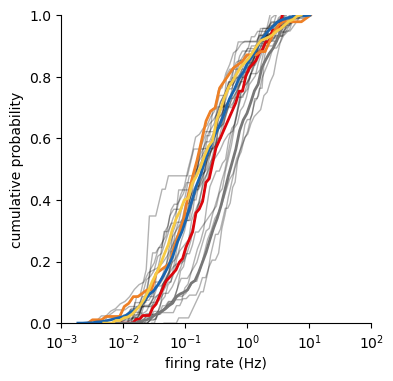

In [31]:
bird_colors = color_utils.get_bird_colors_tol(bird_ids)
fig, ax = waveform_plots.plot_cum_fr(session_rates, session_bins,
                                     bird_rates, bird_bins,
                                     colors=bird_colors
                                    )
fig.savefig(f'{save_figs}cumulative_frs_excite.png', 
                      dpi=600, bbox_inches='tight')

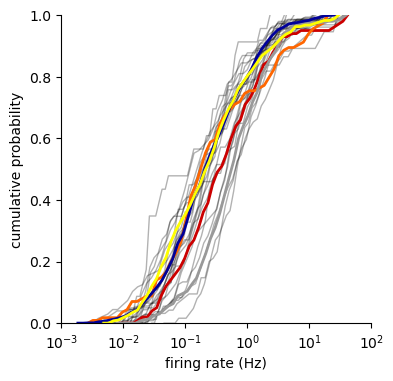

In [12]:
bird_colors = color_utils.get_bird_colors_da(bird_ids, adjust_colors)
fig, ax = waveform_plots.plot_cum_fr(session_rates, session_bins,
                                     bird_rates, bird_bins,
                                     colors=bird_colors
                                    )
fig.savefig(f'{save_figs}cumulative_frs_da.png', 
                      dpi=600, bbox_inches='tight')